### ЧАСТЬ 1: Итоговый датасет
Соберём данные из 12 обработанных файлов для каждого месяца в один и 
получим единую таблицу за 2025 год. Также присоединим к этой таблице данные о концертах. 

In [1]:
import pandas as pd

files = []
for i in range(1, 13):
    files.append(pd.read_parquet(f'../data/processed/taxi/yellow_taxi_pickups_2025_{i:02d}.parquet'))
len(files)

12

In [2]:
taxi = pd.concat(files, ignore_index=True)
taxi

,date,hour,LocationID,pickups
0,2025-01-01,0,79,353
1,2025-01-01,0,161,274
2,2025-01-01,0,163,161
3,2025-01-01,0,186,155
4,2025-01-01,0,239,270
...,...,...,...,...
43795,2025-12-31,23,79,226
43796,2025-12-31,23,161,119
43797,2025-12-31,23,163,60
43798,2025-12-31,23,186,75


In [3]:
# размер таблицы совпадает с ожидаемым 365 дней * 24 часа * 5 зон = 43800 строк
print('Самая ранняя дата в таблице:', taxi["date"].min())
print('Самая поздняя дата в таблице:', taxi["date"].max())
print('Количество уникальных дат:', taxi["date"].nunique())
print('Количество уникальных часов:', taxi["hour"].nunique())
print('Количество уникальных зон такси:', taxi["LocationID"].nunique())

Самая ранняя дата в таблице: 2025-01-01 00:00:00
Самая поздняя дата в таблице: 2025-12-31 00:00:00
Количество уникальных дат: 365
Количество уникальных часов: 24
Количество уникальных зон такси: 5


In [4]:
taxi.isna().sum()

date          0
hour          0
LocationID    0
pickups       0
dtype: int64

In [5]:
# Проверим уникальность записей: нет ли повторов с одинаковой датой, временем и зоной, но разным числом посадок
taxi.duplicated(
    subset=["date", "hour", "LocationID"]
).sum()

np.int64(0)

In [6]:
print('Зоны, которые встречаются в таблице:', taxi["LocationID"].unique())

Зоны, которые встречаются в таблице: [ 79 161 163 186 239]


In [7]:
event_days = pd.read_parquet('../data/processed/events/event_days_2025.parquet')
event_days

,date,venue,LocationID,zone
0,2025-01-08,Madison Square Garden,186,Penn Station/Madison Sq West
1,2025-01-11,Isaac Stern Auditorium,163,Midtown North
2,2025-01-15,Radio City Music Hall,161,Midtown Center
3,2025-01-17,Beacon Theatre,239,Upper West Side South
4,2025-01-17,Webster Hall,79,East Village
...,...,...,...,...
361,2025-12-29,Madison Square Garden,186,Penn Station/Madison Sq West
362,2025-12-30,Beacon Theatre,239,Upper West Side South
363,2025-12-30,Madison Square Garden,186,Penn Station/Madison Sq West
364,2025-12-31,Beacon Theatre,239,Upper West Side South


Название площадки и зоны - информация, которая кодируется с помощью LocationID,
так как для одной зоны у нас одна музыкальная площадка в ней.
Добавление этих названий в таблицу излишне, если понадобится, то восстановим их по id зоны.

In [68]:
events = event_days[['date', 'LocationID']].copy()
events["event_day"] = 1
events

,date,LocationID,event_day
0,2025-01-08,186,1
1,2025-01-11,163,1
2,2025-01-15,161,1
3,2025-01-17,239,1
4,2025-01-17,79,1
...,...,...,...
361,2025-12-29,186,1
362,2025-12-30,239,1
363,2025-12-30,186,1
364,2025-12-31,239,1


Для площадки, на которой в эту дату есть концерт, мы проставляем для каждого часа 1 в признак event_day, то есть независимо от времени проведения концерта признак распространяется на весь день.
Если в признаке стоит 0, значит в этот день на этой площадке не было концерта.

In [9]:
taxi = taxi.merge(events, on=['date', 'LocationID'], how='left')
taxi["event_day"] = taxi["event_day"].fillna(0).astype(int)
taxi

,date,hour,LocationID,pickups,event_day
0,2025-01-01,0,79,353,0
1,2025-01-01,0,161,274,0
2,2025-01-01,0,163,161,0
3,2025-01-01,0,186,155,0
4,2025-01-01,0,239,270,0
...,...,...,...,...,...
43795,2025-12-31,23,79,226,0
43796,2025-12-31,23,161,119,0
43797,2025-12-31,23,163,60,0
43798,2025-12-31,23,186,75,1


In [72]:
# Ожидаемо, у нас 366 записей о концертных датах для площадок и для каждого дня и зоны есть 24 часа, 
# тогда 1 стоит в 366 концертных дней * 24 часа = 8784 ячейках
taxi["event_day"].value_counts()

event_day
0    35016
1     8784
Name: count, dtype: int64

### ЧАСТЬ 2: Сравнение профилей на основе event_day
#### ПУНКТ 1: Сравнение средних
Рассмотрим среднее число поездок в каждом районе для дат с event_day = 1 и для дат с event_day = 0.


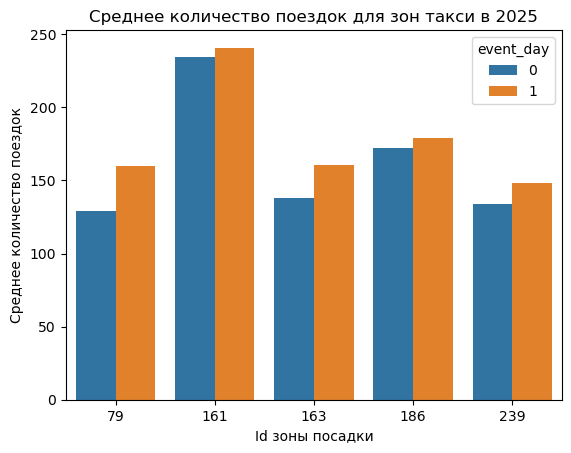

In [11]:
import seaborn as sns


gr = taxi.groupby(['LocationID', 'event_day'])['pickups'].mean().rename('pickups_mean')
gr = gr.to_frame()
sns.barplot(data=gr, x='LocationID', y='pickups_mean', hue='event_day').set(
    title="Среднее количество поездок для зон такси в 2025", 
    xlabel="Id зоны посадки", 
    ylabel="Среднее количество поездок");

#### ПУНКТ 2: Сравнение средних с учётом часового разбиения

Для каждой зоны посадки заметно, что в день концерта среднее количество посадок немного возрастает. Исследуем это возможное влияние, рассмотрев почасовой профиль для каждой зоны 

In [12]:
hourly_profile = taxi.groupby(['LocationID', 'event_day', 'hour'])['pickups'].mean().rename('pickups_mean')
hourly_profile = hourly_profile.to_frame()
hourly_profile = hourly_profile.reset_index()
hourly_profile

,LocationID,event_day,hour,pickups_mean
0,79,0,0,264.128906
1,79,0,1,240.941406
2,79,0,2,176.031250
3,79,0,3,115.453125
4,79,0,4,58.027344
...,...,...,...,...
235,239,1,19,216.308642
236,239,1,20,175.555556
237,239,1,21,199.444444
238,239,1,22,200.469136


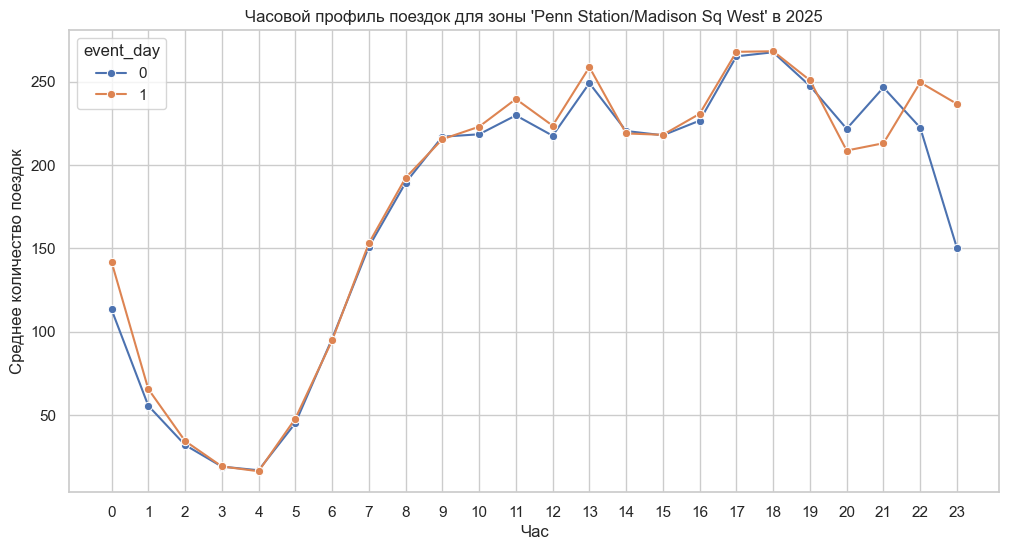

In [13]:
# Рассмотрим часовой профиль для зоны 186 = 'Penn Station/Madison Sq West', 
# в ней находится площадка Madison Square Garden

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

hourly_profile_MSG = hourly_profile[hourly_profile['LocationID'] == 186]
sns.lineplot(
    data=hourly_profile_MSG, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок для зоны 'Penn Station/Madison Sq West' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

Повышение среднего количества поездок происходит в концертные дни: в дневные часы (10-13) и в ночные (0-1, 22-23),  по сравнению с неконцертными днями. Причём перед резким ростом среднего количества поездок в вечерние часы (22-23) происходит падение (20-21).

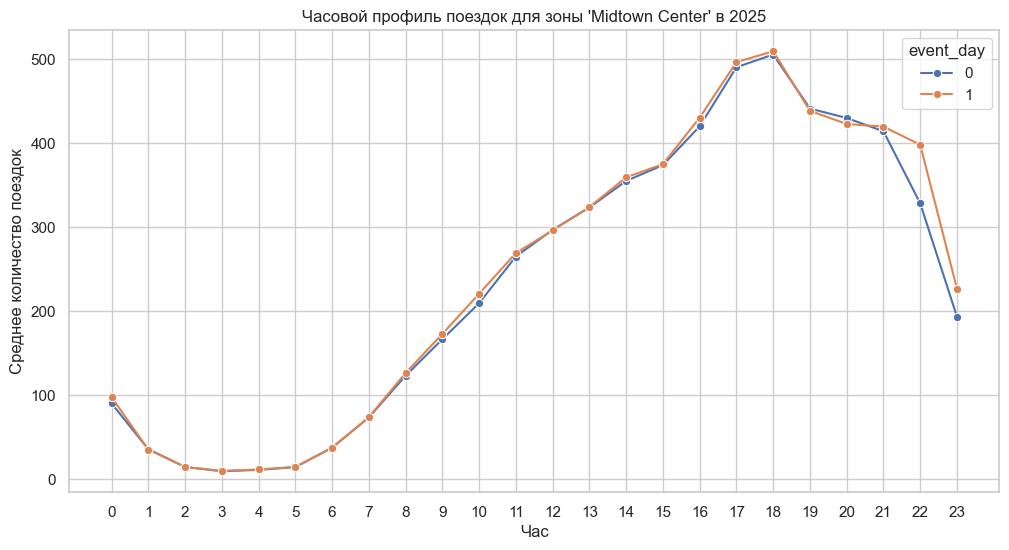

In [14]:
# Аналогично построим графики для остальных зон 
# Зона 161 = 'Midtown Center', площадка 'Radio City Music Hall'

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

hourly_profile_RCMH = hourly_profile[hourly_profile['LocationID'] == 161]

sns.lineplot(
    data=hourly_profile_RCMH, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок для зоны 'Midtown Center' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

Явные отличия наблюдаются в вечерние часы (22-23) среднее количество поездок на такси в концертные дни повышается.

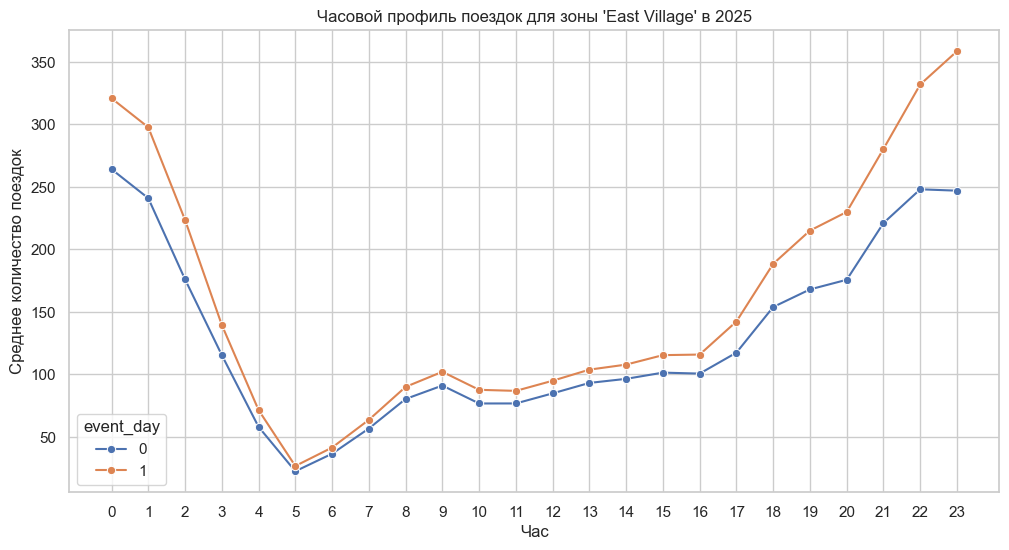

In [15]:
# Зона 79 = 'East Village', площадка 'Webster Hall'

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

hourly_profile_WH = hourly_profile[hourly_profile['LocationID'] == 79]

sns.lineplot(
    data=hourly_profile_WH, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок для зоны 'East Village' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

Среднее количество поездок на такси повышается для каждого часа в концертные дни. Особенно сильный рост заметен в вечерние и ночные часы (0-3, 19-23).Общее повышение среднего количества поездок может сигнализировать о том, что концертные даты приходятся на более загруженные дни и необходимо включить в анализ день недели. Велик риск конфаундинга календарём.

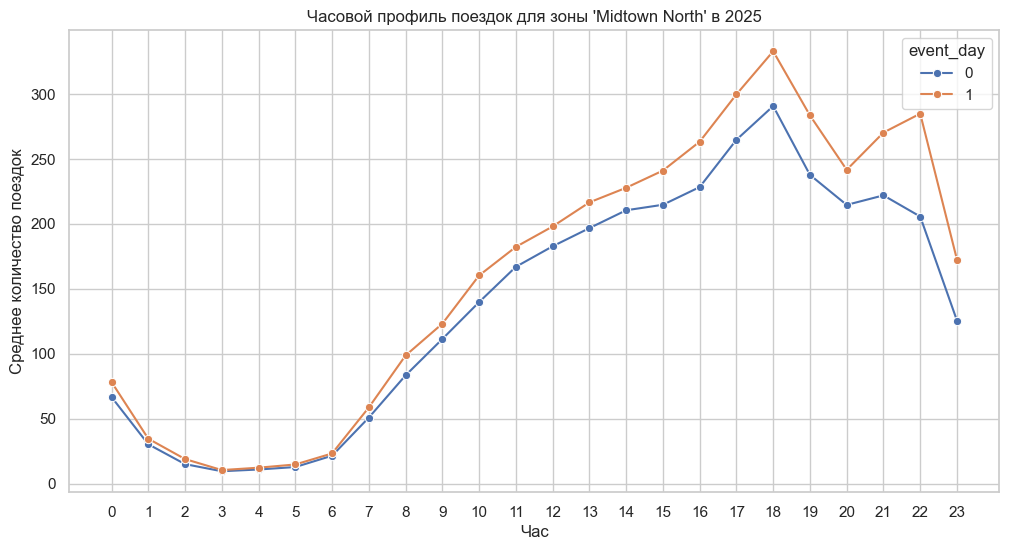

In [16]:
# Зона 163 = 'Midtown North', площадка 'Isaac Stern Auditorium'

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

hourly_profile_ISA = hourly_profile[hourly_profile['LocationID'] == 163]

sns.lineplot(
    data=hourly_profile_ISA, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок для зоны 'Midtown North' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

Среднее количество поездок на такси повышается в концертные даты днём и вечером (15-23). Особенно сильный рост заметен поздним вечером (21-23). 

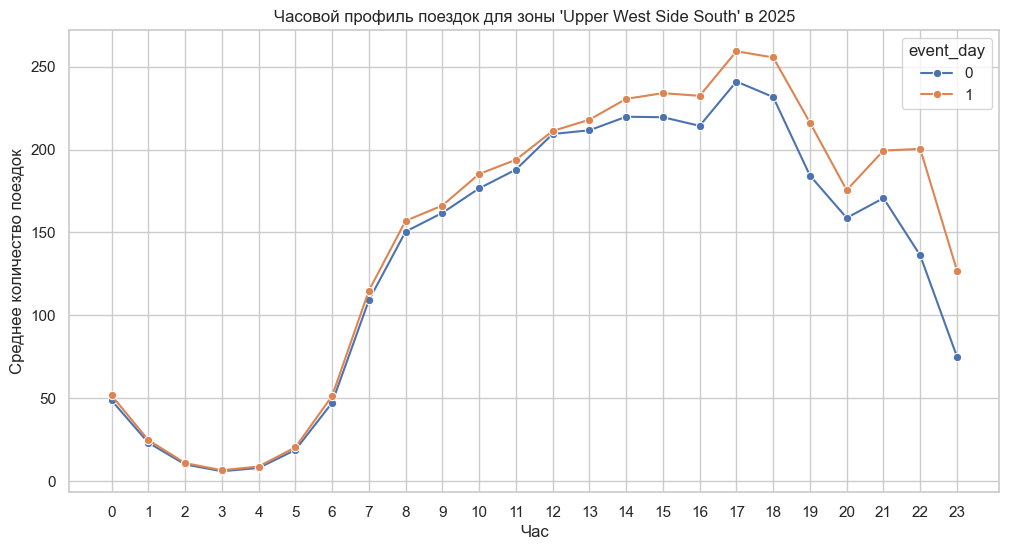

In [17]:
# Зона 239 = 'Upper West Side South', площадка 'Beacon Theatre'

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

hourly_profile_BT = hourly_profile[hourly_profile['LocationID'] == 239]

sns.lineplot(
    data=hourly_profile_BT, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок для зоны 'Upper West Side South' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

Среднее количество поездок на такси повышается в концертные дни днём и вечером (15-23). Особенно сильный рост заметен поздним вечером (21-23).

#### ПУНКТ 3: Сравнение средних с учётом часового разбиения и дня недели

Исследуем среднее количество поездок в зависимости от дня недели. Ожидаем 7 дней * 5 зон * 2 (бинарный признак) = 70 строк.

In [18]:
taxi['weekday'] = taxi['date'].dt.day_name()
weekly_profile = taxi.groupby(['LocationID', 'weekday', 'event_day'])['pickups'].mean().rename('pickups_mean')
weekly_profile = weekly_profile.to_frame()
weekly_profile = weekly_profile.reset_index()
weekly_profile

,LocationID,weekday,event_day,pickups_mean
0,79,Friday,0,142.911290
1,79,Friday,1,155.601190
2,79,Monday,0,70.807018
3,79,Monday,1,72.681548
4,79,Saturday,0,226.615278
...,...,...,...,...
65,239,Thursday,1,161.833333
66,239,Tuesday,0,131.135684
67,239,Tuesday,1,149.089744
68,239,Wednesday,0,138.823465


Перед анализом посмотрим, сколько у нас концертных и неконцертных дат
для каждого дня недели. Это позволит понять, достаточно ли наблюдений
для сравнения средних или для некоторых комбинаций концертных дат слишком мало.

Ожидаем 7 дней * 5 зон = 35 строк для каждого из типов дат. Условно, будем считать, что для  описательного сравнения приемлемо 5 концертных дат.

In [19]:
days = taxi[["date", "LocationID", "weekday", "event_day"]].drop_duplicates()
days_count = (
    days
    .groupby(["LocationID", "weekday", "event_day"])
    .size()
    .rename("days_count")
    .reset_index()
)

# Начнём с проверки концертных дней.
days_count[(days_count["event_day"] == 1) & (days_count["days_count"] < 5)].sort_values("days_count")

,LocationID,weekday,event_day,days_count
35,163,Sunday,1,1
39,163,Tuesday,1,1
17,161,Monday,1,3
41,163,Wednesday,1,3
31,163,Monday,1,4


In [20]:
days_count[(days_count["event_day"] == 0) & (days_count["days_count"] < 5)].sort_values("days_count")

,LocationID,weekday,event_day,days_count


У неконцертных комбинаций нет проблемных записей. Из 35 комбинаций LocationID × weekday только 5 имеют меньше 5 концертных дат. Из них четыре записи имеют LocationID = 163, то есть особенно осторожно нужно относиться к Midtown North / Isaac Stern Auditorium. Для 161 проблема только с понедельниками. Остальные комбинации можно использовать для описательного сравнения гораздо увереннее.

Теперь посмотрим, сохраняются ли различия в почасовых профилях после учёта дня недели. Построим таблицу LocationID × weekday × hour × event_day.

Ожидаем 5 зон × 7 дней × 24 часа × 2 (бинарный признак) = 1680 строк.

In [21]:
weekly_hourly_profile = (
    taxi
    .groupby(["LocationID", "weekday", "hour", "event_day"])["pickups"]
    .mean()
    .rename("pickups_mean")
    .reset_index()
)
weekly_hourly_profile

,LocationID,weekday,hour,event_day,pickups_mean
0,79,Friday,0,0,220.838710
1,79,Friday,0,1,231.476190
2,79,Friday,1,0,135.935484
3,79,Friday,1,1,146.380952
4,79,Friday,2,0,96.709677
...,...,...,...,...,...
1675,239,Wednesday,21,1,216.133333
1676,239,Wednesday,22,0,140.763158
1677,239,Wednesday,22,1,209.800000
1678,239,Wednesday,23,0,61.052632


Сейчас различие уже нельзя будет объяснить тем, что концерты чаще проходят по пятницам или субботам. Теперь мы можем, например, сравнивать поездки в концертную пятницу и неконцертную пятницу в конкретных зонах.

Для каждой зоны рассмотрим почасовые профили по дням недели и сравним концертные и неконцертные дни. Всего возможно 35 таких сравнений. Сначала рассмотрим самую крупную концертную площадку - Madison Square Garden (LocationID = 186, зона Penn Station/Madison Sq West).

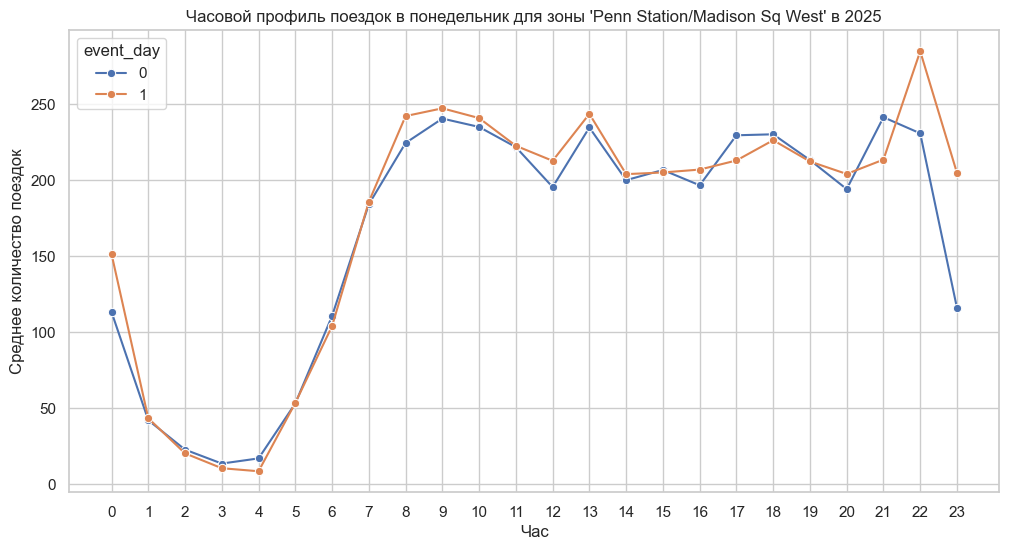

In [22]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

weekly_hourly_profile_MSG_1 = weekly_hourly_profile[
    (weekly_hourly_profile['LocationID'] == 186) & 
    (weekly_hourly_profile['weekday'] == 'Monday')]
sns.lineplot(
    data=weekly_hourly_profile_MSG_1, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок в понедельник для зоны 'Penn Station/Madison Sq West' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

В течение дня наблюдаются малые различия в количестве поездок для концертных и неконцертных дней. Выраженные различия заметны в вечернее время, в 21 происходит рост среднего количества поездок в 
неконцертные дни, а после происходит резкий скачок в концертные дни.

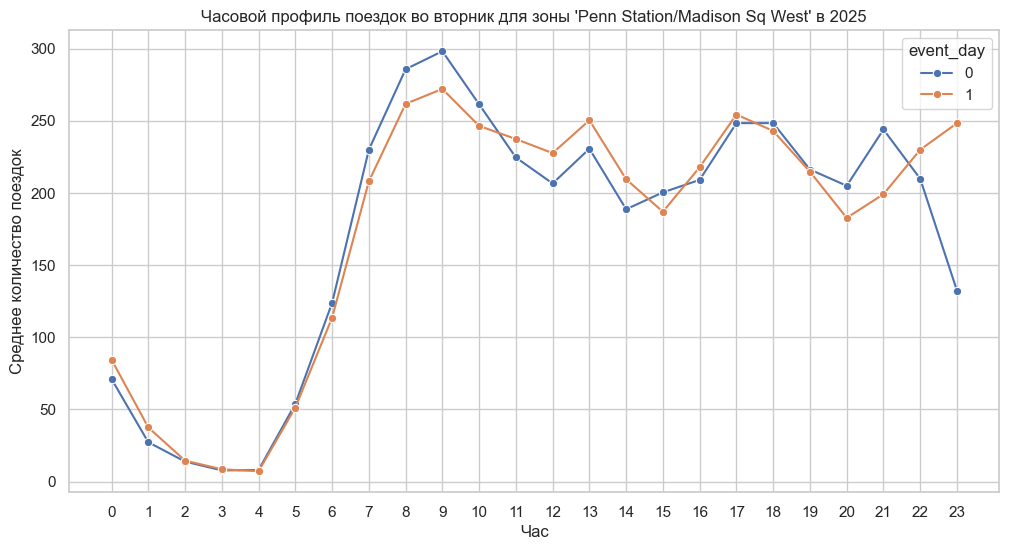

In [23]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

weekly_hourly_profile_MSG_2 = weekly_hourly_profile[
    (weekly_hourly_profile['LocationID'] == 186) & 
    (weekly_hourly_profile['weekday'] == 'Tuesday')]
sns.lineplot(
    data=weekly_hourly_profile_MSG_2, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок во вторник для зоны 'Penn Station/Madison Sq West' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

Аналогично понедельнику, во вторник наблюдаем в течение большей части дня малые отличия, вечером происходит сначала увеличение среднего для неконцертных дней, после - резкий рост среднего для концертных. Интересно, что тут рост среднего утром неконцертных дней (8-9) явно выражен.

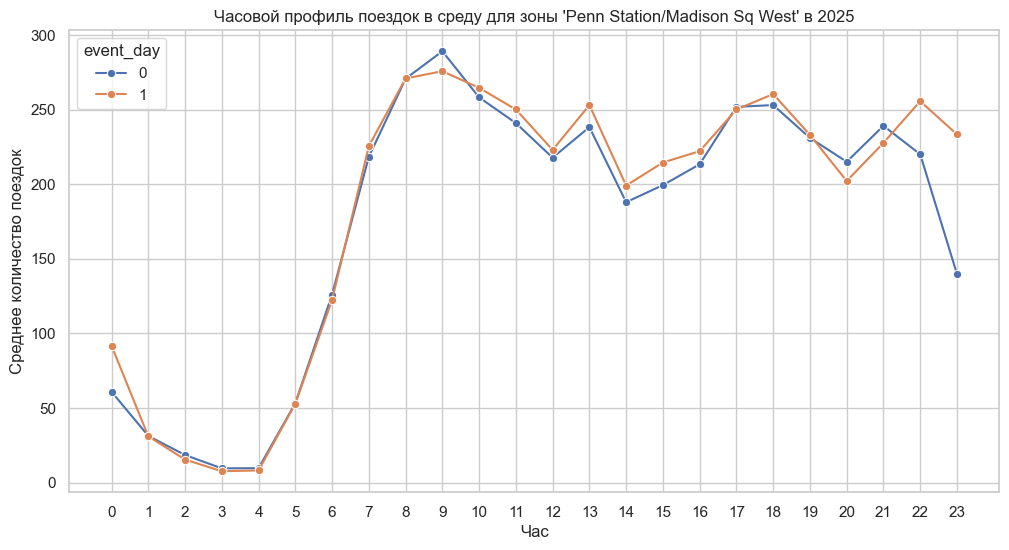

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

weekly_hourly_profile_MSG_3 = weekly_hourly_profile[
    (weekly_hourly_profile['LocationID'] == 186) & 
    (weekly_hourly_profile['weekday'] == 'Wednesday')]
sns.lineplot(
    data=weekly_hourly_profile_MSG_3, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок в среду для зоны 'Penn Station/Madison Sq West' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

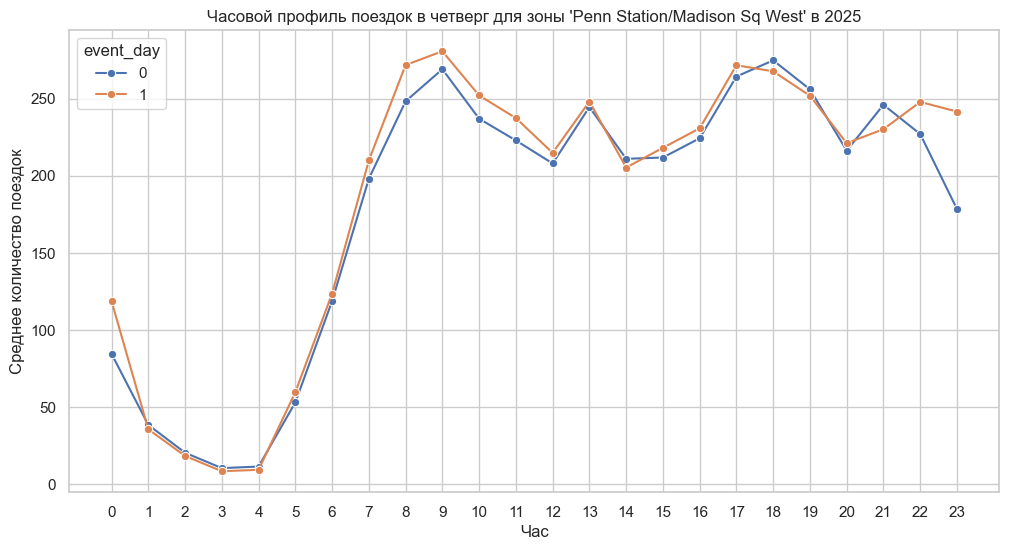

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

weekly_hourly_profile_MSG_4 = weekly_hourly_profile[
    (weekly_hourly_profile['LocationID'] == 186) & 
    (weekly_hourly_profile['weekday'] == 'Thursday')]
sns.lineplot(
    data=weekly_hourly_profile_MSG_4, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок в четверг для зоны 'Penn Station/Madison Sq West' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

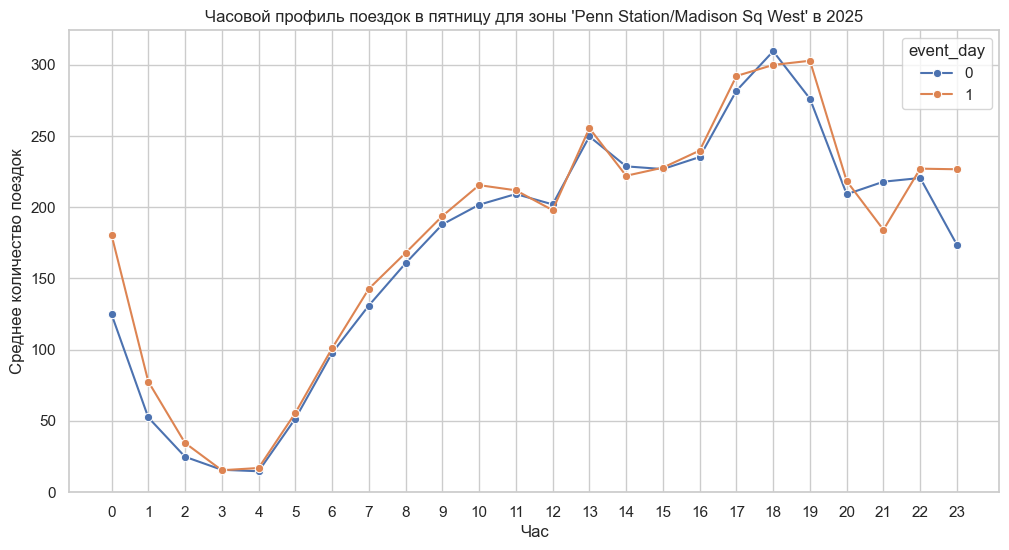

In [26]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

weekly_hourly_profile_MSG_5 = weekly_hourly_profile[
    (weekly_hourly_profile['LocationID'] == 186) & 
    (weekly_hourly_profile['weekday'] == 'Friday')]
sns.lineplot(
    data=weekly_hourly_profile_MSG_5, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок в пятницу для зоны 'Penn Station/Madison Sq West' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

На графиках со среды по пятницу наблюдаем паттерн понедельника. Малые отклонения в течение дня, вечером сначала падение среднего в концертные дни, а после резкий рост. 

Таким образом, для будних дней в зоне Madison Square Garden наблюдается устойчивый вечерний паттерн: непосредственно перед поздним вечерним ростом среднее количество поездок в концертные дни несколько снижается относительно неконцертных, а в 22–23 ч становится выше.

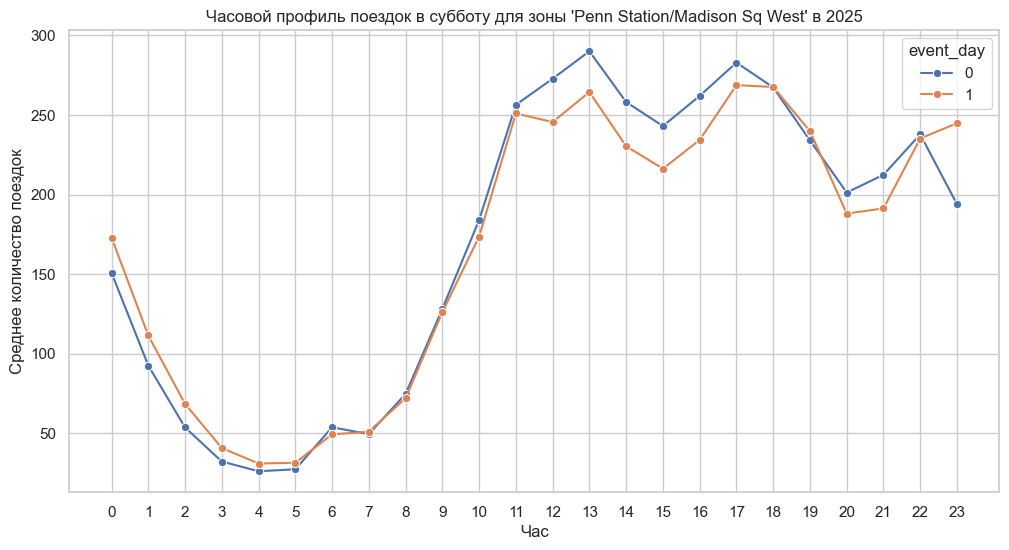

In [27]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

weekly_hourly_profile_MSG_6 = weekly_hourly_profile[
    (weekly_hourly_profile['LocationID'] == 186) & 
    (weekly_hourly_profile['weekday'] == 'Saturday')]
sns.lineplot(
    data=weekly_hourly_profile_MSG_6, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок в субботу для зоны 'Penn Station/Madison Sq West' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

В субботу, до 11 часов включительно наблюдаются лишь малые отличия в средних, с 12 до 17 часов заметно преобладает среднее в неконцертные дни. Вечером наблюдаем знакомый паттерн: падение среднего количества поездок в концертные дни в 20-21 ч и резкий его рост после.

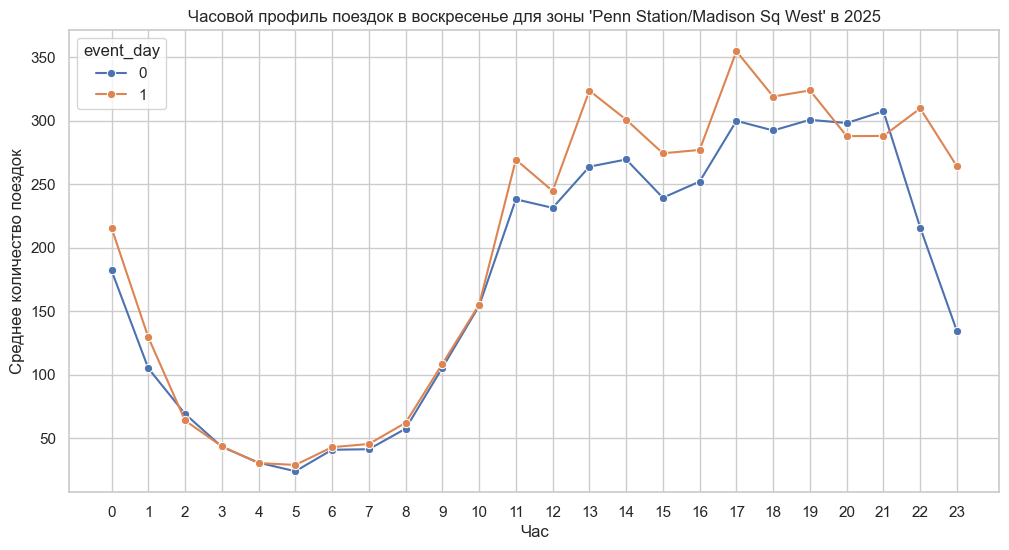

In [28]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

weekly_hourly_profile_MSG_7 = weekly_hourly_profile[
    (weekly_hourly_profile['LocationID'] == 186) & 
    (weekly_hourly_profile['weekday'] == 'Sunday')]
sns.lineplot(
    data=weekly_hourly_profile_MSG_7, 
    x='hour', 
    y='pickups_mean', 
    hue='event_day', 
    marker="o").set(
    title="Часовой профиль поездок в воскресенье для зоны 'Penn Station/Madison Sq West' в 2025", 
    xlabel="Час", 
    ylabel="Среднее количество поездок")

plt.xticks(range(24))

plt.show()

В воскресенье заметен активный рост среднего для концертных дней в 11-19 ч, после чего вечером наблюдаем знакомое поведение.

Итак, в зоне Madison Square Garden наблюдается устойчивый вечерний паттерн:
- 20–21 → концертные дни часто ниже, иногда не выше или слегка отклоняются
- 22–23 → концертные дни заметно выше.

Рассматривать оставшиеся 28 графиков для 4 зон трудоёмко, удобнее рассмотреть хитмапы для разницы средних в концертные и неконцертные дни сразу для всей недели.

Начнём с площадки 'Radio City Music Hall' (зона 161 = 'Midtown Center').

Минимальная разница: -75.8, Sunday, 15:00
Максимальная разница: 112.7, Tuesday, 22:00


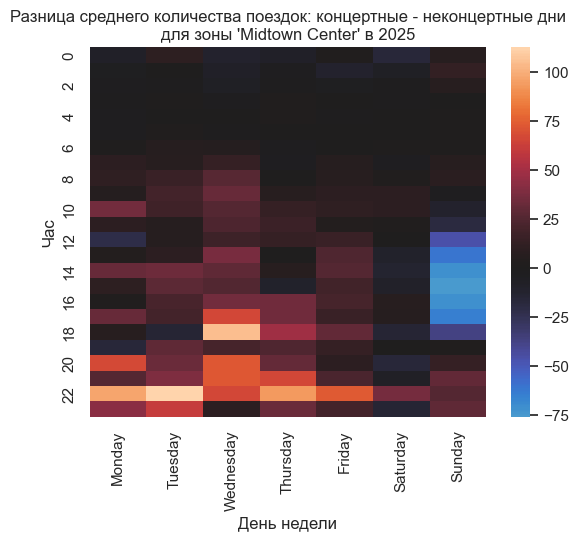

In [62]:
weekly_hourly_profile_RCMH = weekly_hourly_profile[
    weekly_hourly_profile['LocationID'] == 161
].copy()

diff_RCMH = weekly_hourly_profile_RCMH.pivot(
    index=["weekday", "hour"],
    columns="event_day",
    values="pickups_mean"
).reset_index()

diff_RCMH["diff_pickups_mean"] = (
    diff_RCMH[1] - diff_RCMH[0]
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

pivot_RCMH = diff_RCMH.pivot(
    index="hour",
    columns="weekday",
    values="diff_pickups_mean"
)

pivot_RCMH = pivot_RCMH[weekday_order]

sns.heatmap(pivot_RCMH, center=0).set(
    title="Разница среднего количества поездок: концертные - неконцертные дни\n"
          "для зоны 'Midtown Center' в 2025",
    xlabel="День недели",
    ylabel="Час"
);

min_diff = diff_RCMH["diff_pickups_mean"].min()
max_diff = diff_RCMH["diff_pickups_mean"].max()
min_row = diff_RCMH.loc[diff_RCMH["diff_pickups_mean"].idxmin()]
max_row = diff_RCMH.loc[diff_RCMH["diff_pickups_mean"].idxmax()]
print(
    f"Минимальная разница: {min_row['diff_pickups_mean']:.1f}, "
    f"{min_row['weekday']}, {min_row['hour']}:00"
)
print(
    f"Максимальная разница: {max_row['diff_pickups_mean']:.1f}, "
    f"{max_row['weekday']}, {max_row['hour']}:00"
)

Заметно, что в будние дни наиболее устойчивое положительное различие наблюдается поздним вечером, особенно в 22 часа, в утреннее и дневное время увеличение умеренное. В выходные ситуация сильно отличается. В воскресенье днём (12-18) сильно возрастает неконцертное среднее, вечером позже 20 часов оно становится меньше.

Минимальная разница: -44.9, Tuesday, 21:00
Максимальная разница: 129.8, Sunday, 23:00


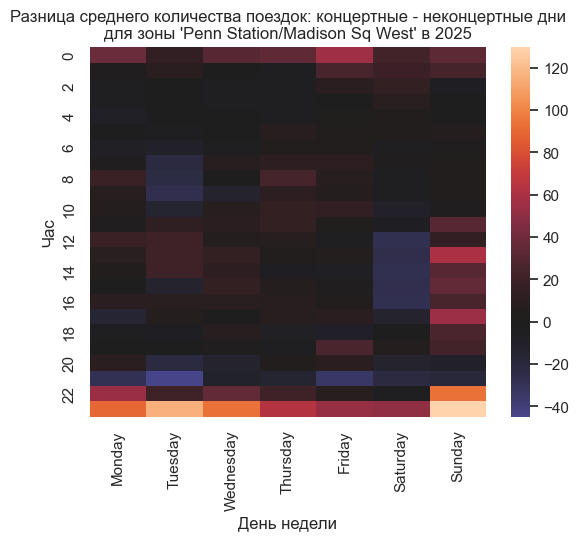

In [64]:
weekly_hourly_profile_MSG = weekly_hourly_profile[
    weekly_hourly_profile['LocationID'] == 186
].copy()

diff_MSG = weekly_hourly_profile_MSG.pivot(
    index=["weekday", "hour"],
    columns="event_day",
    values="pickups_mean"
).reset_index()

diff_MSG["diff_pickups_mean"] = (
    diff_MSG[1] - diff_MSG[0]
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

pivot_MSG = diff_MSG.pivot(
    index="hour",
    columns="weekday",
    values="diff_pickups_mean"
)

pivot_MSG = pivot_MSG[weekday_order]

sns.heatmap(pivot_MSG, center=0).set(
    title="Разница среднего количества поездок: концертные - неконцертные дни\n"
          "для зоны 'Penn Station/Madison Sq West' в 2025",
    xlabel="День недели",
    ylabel="Час"
);

min_diff = diff_MSG["diff_pickups_mean"].min()
max_diff = diff_MSG["diff_pickups_mean"].max()
min_row = diff_MSG.loc[diff_MSG["diff_pickups_mean"].idxmin()]
max_row = diff_MSG.loc[diff_MSG["diff_pickups_mean"].idxmax()]
print(
    f"Минимальная разница: {min_row['diff_pickups_mean']:.1f}, "
    f"{min_row['weekday']}, {min_row['hour']}:00"
)
print(
    f"Максимальная разница: {max_row['diff_pickups_mean']:.1f}, "
    f"{max_row['weekday']}, {max_row['hour']}:00"
)

Для полноты анализа добавлю и зону 'Penn Station/Madison Sq West', хотя отдельно я её уже рассмотрела выше, и продублирую вывод. В зоне Madison Square Garden наблюдается устойчивый вечерний паттерн:
- 20–21 → концертные дни часто ниже, иногда не выше или слегка отклоняются
- 22–23 → концертные дни заметно выше.

Минимальная разница: -19.4, Monday, 0:00
Максимальная разница: 153.4, Saturday, 1:00


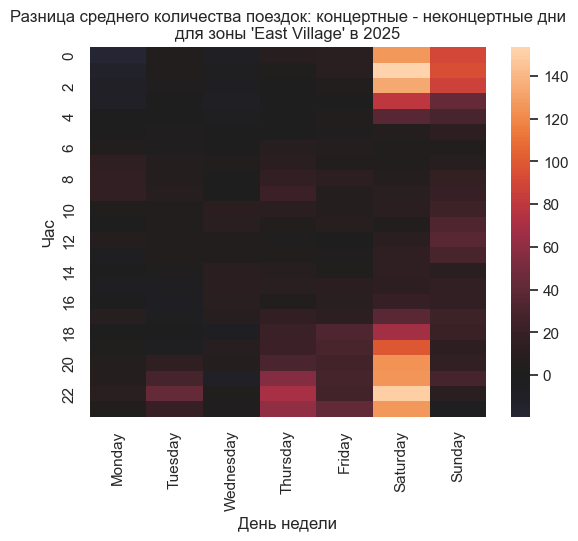

In [65]:
# Зона 79 = 'East Village', площадка 'Webster Hall'

weekly_hourly_profile_WH = weekly_hourly_profile[
    weekly_hourly_profile['LocationID'] == 79
].copy()

diff_WH = weekly_hourly_profile_WH.pivot(
    index=["weekday", "hour"],
    columns="event_day",
    values="pickups_mean"
).reset_index()

diff_WH["diff_pickups_mean"] = (
    diff_WH[1] - diff_WH[0]
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

pivot_WH = diff_WH.pivot(
    index="hour",
    columns="weekday",
    values="diff_pickups_mean"
)

pivot_WH = pivot_WH[weekday_order]

sns.heatmap(pivot_WH, center=0).set(
    title="Разница среднего количества поездок: концертные - неконцертные дни\n"
          "для зоны 'East Village' в 2025",
    xlabel="День недели",
    ylabel="Час"
);

min_diff = diff_WH["diff_pickups_mean"].min()
max_diff = diff_WH["diff_pickups_mean"].max()
min_row = diff_WH.loc[diff_WH["diff_pickups_mean"].idxmin()]
max_row = diff_WH.loc[diff_WH["diff_pickups_mean"].idxmax()]
print(
    f"Минимальная разница: {min_row['diff_pickups_mean']:.1f}, "
    f"{min_row['weekday']}, {min_row['hour']}:00"
)
print(
    f"Максимальная разница: {max_row['diff_pickups_mean']:.1f}, "
    f"{max_row['weekday']}, {max_row['hour']}:00"
)

Различия в большинстве будних часов небольшие, наиболее заметное положительное различие наблюдается в четверг вечером. В субботу вечером и ночью (0-3, 18-23), в воскресенье ночью (0-2) происходит резкий скачок концертного среднего.

Минимальная разница: -13.1, Sunday, 23:00
Максимальная разница: 102.4, Tuesday, 22:00


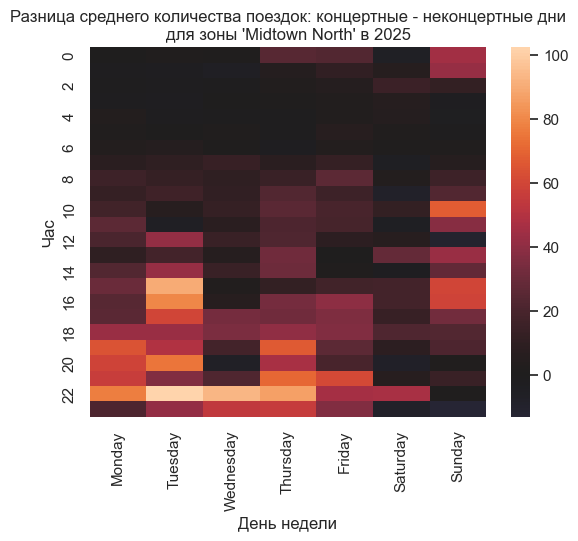

In [66]:
# Зона 163 = 'Midtown North', площадка 'Isaac Stern Auditorium'

weekly_hourly_profile_ISA = weekly_hourly_profile[
    weekly_hourly_profile['LocationID'] == 163
].copy()

diff_ISA = weekly_hourly_profile_ISA.pivot(
    index=["weekday", "hour"],
    columns="event_day",
    values="pickups_mean"
).reset_index()

diff_ISA["diff_pickups_mean"] = (
    diff_ISA[1] - diff_ISA[0]
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

pivot_ISA = diff_ISA.pivot(
    index="hour",
    columns="weekday",
    values="diff_pickups_mean"
)

pivot_ISA = pivot_ISA[weekday_order]

sns.heatmap(pivot_ISA, center=0).set(
    title="Разница среднего количества поездок: концертные - неконцертные дни\n"
          "для зоны 'Midtown North' в 2025",
    xlabel="День недели",
    ylabel="Час"
);

min_diff = diff_ISA["diff_pickups_mean"].min()
max_diff = diff_ISA["diff_pickups_mean"].max()
min_row = diff_ISA.loc[diff_ISA["diff_pickups_mean"].idxmin()]
max_row = diff_ISA.loc[diff_ISA["diff_pickups_mean"].idxmax()]
print(
    f"Минимальная разница: {min_row['diff_pickups_mean']:.1f}, "
    f"{min_row['weekday']}, {min_row['hour']}:00"
)
print(
    f"Максимальная разница: {max_row['diff_pickups_mean']:.1f}, "
    f"{max_row['weekday']}, {max_row['hour']}:00"
)

Отрицательных различий почти нет, а в будни чаще наблюдаем положительные, особенно к вечеру и около 22 часов. В воскресенье днём, а не вечером концертное среднее становится больше.

Сравнения для понедельника, вторника, среды и воскресенья следует интерпретировать осторожно, так как сравнение основано на малом числе концертных дат и нестабильно.

Минимальная разница: -36.8, Sunday, 17:00
Максимальная разница: 85.0, Monday, 22:00


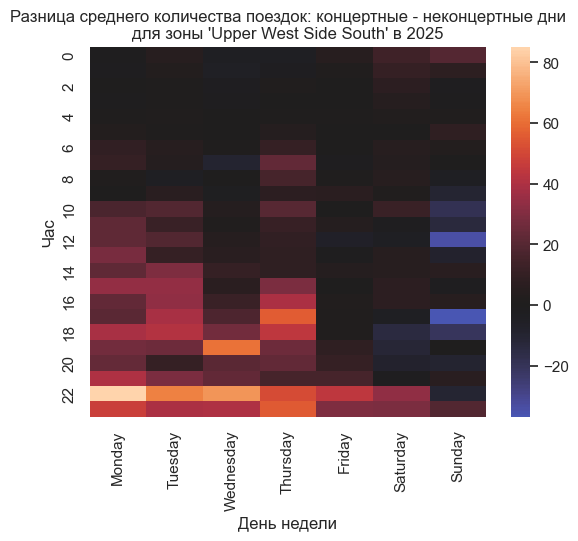

In [67]:
# Зона 239 = 'Upper West Side South', площадка 'Beacon Theatre'

weekly_hourly_profile_BT = weekly_hourly_profile[
    weekly_hourly_profile['LocationID'] == 239
].copy()

diff_BT = weekly_hourly_profile_BT.pivot(
    index=["weekday", "hour"],
    columns="event_day",
    values="pickups_mean"
).reset_index()

diff_BT["diff_pickups_mean"] = (
    diff_BT[1] - diff_BT[0]
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

pivot_BT = diff_BT.pivot(
    index="hour",
    columns="weekday",
    values="diff_pickups_mean"
)

pivot_BT = pivot_BT[weekday_order]

sns.heatmap(pivot_BT, center=0).set(
    title="Разница среднего количества поездок: концертные - неконцертные дни\n"
          "для зоны 'Upper West Side South' в 2025",
    xlabel="День недели",
    ylabel="Час"
);

min_diff = diff_BT["diff_pickups_mean"].min()
max_diff = diff_BT["diff_pickups_mean"].max()
min_row = diff_BT.loc[diff_BT["diff_pickups_mean"].idxmin()]
max_row = diff_BT.loc[diff_BT["diff_pickups_mean"].idxmax()]
print(
    f"Минимальная разница: {min_row['diff_pickups_mean']:.1f}, "
    f"{min_row['weekday']}, {min_row['hour']}:00"
)
print(
    f"Максимальная разница: {max_row['diff_pickups_mean']:.1f}, "
    f"{max_row['weekday']}, {max_row['hour']}:00"
)

В будние дни в основном преобладает концертное среднее, особенно в 22 часа. В субботу также в 22 часа и позже оно становится больше неконцертного, но сравнительно меньше, чем в будни. В воскресенье в дневное время преобладает неконцертное среднее.

#### ПУНКТ 4: Вывод

После контроля дня недели информация о наличии концерта по-прежнему связана с изменением почасового профиля поездок Yellow Taxi. Наиболее устойчивое различие для нескольких площадок наблюдается в поздние вечерние часы, особенно около 22–23 часов, когда среднее количество посадок в концертные дни часто выше. При этом характер эффекта зависит от площадки и дня недели: для некоторых зон наблюдаются дополнительные дневные или ночные различия. Следовательно, бинарный признак event_day содержит потенциально полезный предиктивный сигнал, однако его эффект неоднороден по часам и площадкам.

### ЧАСТЬ 3: Сохранение итогового датасета

In [70]:
from pathlib import Path

output_path = Path("../data/processed/final_dataset_2025.parquet")

taxi.to_parquet(
    output_path,
    index=False
)